# Exploratory Data Analysis and Preprocessing
## Synthetic Health Insurance Claims Data

**Dataset:** Apex Synthetic Health Insurance Claims Fraud Detection<br>
**Source:** Kaggle<br>
**Purpose:** Understand data structure, identify patterns, and prepare data for anomaly detection models<br>

##  1. Setup and Data Loading
### 1.1 Import Libraries

In [3]:
#Data manipulation
import pandas as pd 
import numpy as np

#Visualization
import matplotlib.pyplot as plt 
import seaborn as sns

#Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

#Utilities
import warnings
warnings.filterwarnings("ignore")

#Set style for better visualizations
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("husl")

#Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: '%.2f' % x)


### 1.2 Load Dataset

In [4]:
#Load the dataset
df = pd.read_csv("../data/healthcare_sample_10k.csv")
print(f"Dataset loaded successfully!")
print(f"Shape: {df.shape}")
print(f"Number of columns: {len(df.columns)}")
print(f"Number of rows: {len(df):,}")

Dataset loaded successfully!
Shape: (10000, 10)
Number of columns: 10
Number of rows: 10,000


### 1.3 Quick Overview

In [5]:
#Display first few rows
df.head()
#Display data types and memory usage
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   claim_id              10000 non-null  str    
 1   patient_id            10000 non-null  str    
 2   provider_npi          10000 non-null  str    
 3   date_of_service       10000 non-null  str    
 4   icd10_diagnosis_code  10000 non-null  str    
 5   cpt_procedure_code    10000 non-null  int64  
 6   billed_amount         10000 non-null  float64
 7   claim_status          10000 non-null  str    
 8   is_anomaly            10000 non-null  int64  
 9   anomaly_type          394 non-null    str    
dtypes: float64(1), int64(2), str(7)
memory usage: 1.7 MB


## 2. Data Exploration
### 2.1 Data Summary

In [6]:
# Statistical summary of numeric columns
df.describe()

,cpt_procedure_code,billed_amount,is_anomaly
count,10000.00,10000.00,10000.00
mean,85512.24,330.50,0.04
std,20674.71,776.08,0.19
min,36415.00,25.00,0.00
25%,85025.00,66.43,0.00
50%,99213.00,157.71,0.00
75%,99284.00,365.32,0.00
max,99285.00,44886.64,1.00


In [7]:
#Unique values in categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    print(f"{col}: {df[col].nunique()} unique values")

claim_id: 10000 unique values
patient_id: 9803 unique values
provider_npi: 7193 unique values
date_of_service: 10000 unique values
icd10_diagnosis_code: 8 unique values
claim_status: 3 unique values
anomaly_type: 2 unique values


### 2.2 Missing Values Analysis

Columns with missing values: 1
anomaly_type    9606
dtype: int64


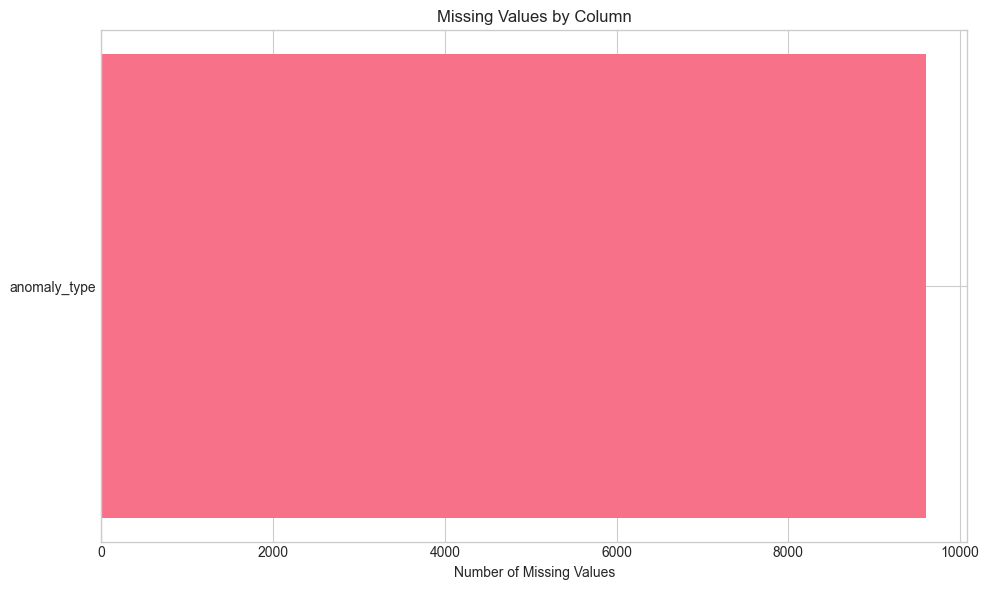

In [9]:
#check for missing values
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)

if len(missing_values) > 0:
    print(f"Columns with missing values: {len(missing_values)}")
    print(missing_values)

    #visualize missing values
    plt.figure(figsize=(10, 6))
    plt.barh(missing_values.index, missing_values.values)
    plt.xlabel("Number of Missing Values")
    plt.title("Missing Values by Column")
    plt.tight_layout()
    plt.show()

else:
    print("No missing values found in the dataset.")

### 2.3 Target Variable Analysis


Fraud Distribution:
is_anomaly
0    9606
1     394
Name: count, dtype: int64

Fraud Percentage: 3.94%


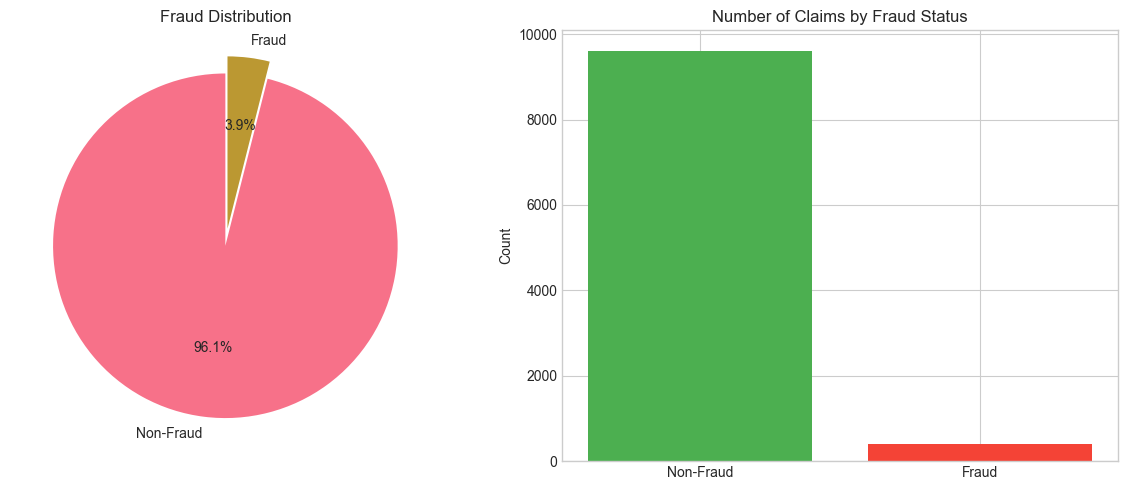

In [12]:
# Distribution of fraudulent vs non-fraudulent claims
fraud_distribution = df['is_anomaly'].value_counts()
print(f"Fraud Distribution:\n{fraud_distribution}")
print(f"\nFraud Percentage: {df['is_anomaly'].mean() * 100:.2f}%")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pie chart
axes[0].pie(fraud_distribution.values, labels=['Non-Fraud', 'Fraud'], 
            autopct='%1.1f%%', explode=(0, 0.1), startangle=90)
axes[0].set_title('Fraud Distribution')

# Bar chart
colors = ['#4CAF50', '#F44336']
axes[1].bar(['Non-Fraud', 'Fraud'], fraud_distribution.values, color=colors)
axes[1].set_ylabel('Count')
axes[1].set_title('Number of Claims by Fraud Status')

plt.tight_layout()
plt.show()


## 3. Univariate Analysis

### 3.1 Numeric Features Analysis
#### 3.1.1 Claim Amount

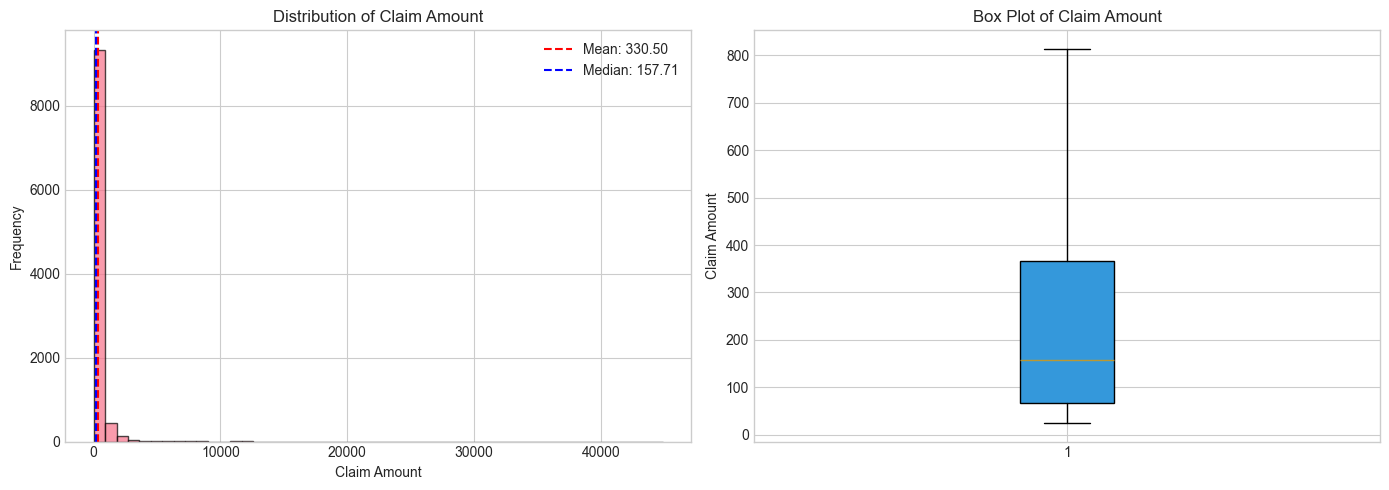

Claim Amount Statistics:
  Mean: 330.50
  Median: 157.71
  Std: 776.08
  Min: 25.00
  Max: 44886.64
  Skewness: 25.05
  Kurtosis: 1190.60


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['billed_amount'], bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(df['billed_amount'].mean(), color='red', linestyle='--', label=f'Mean: {df["billed_amount"].mean():.2f}')
axes[0].axvline(df['billed_amount'].median(), color='blue', linestyle='--', label=f'Median: {df["billed_amount"].median():.2f}')
axes[0].set_xlabel('Claim Amount')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Claim Amount')
axes[0].legend()

# Box plot
box = axes[1].boxplot(df['billed_amount'], vert=True, patch_artist=True, showfliers=False)
box['boxes'][0].set_facecolor('#3498db')
axes[1].set_ylabel('Claim Amount')
axes[1].set_title('Box Plot of Claim Amount')

plt.tight_layout()
plt.show()

# Summary statistics
print("Claim Amount Statistics:")
print(f"  Mean: {df['billed_amount'].mean():.2f}")
print(f"  Median: {df['billed_amount'].median():.2f}")
print(f"  Std: {df['billed_amount'].std():.2f}")
print(f"  Min: {df['billed_amount'].min():.2f}")
print(f"  Max: {df['billed_amount'].max():.2f}")
print(f"  Skewness: {df['billed_amount'].skew():.2f}")
print(f"  Kurtosis: {df['billed_amount'].kurtosis():.2f}")




#### 3.1.2 Claim Amount by Fraud Status

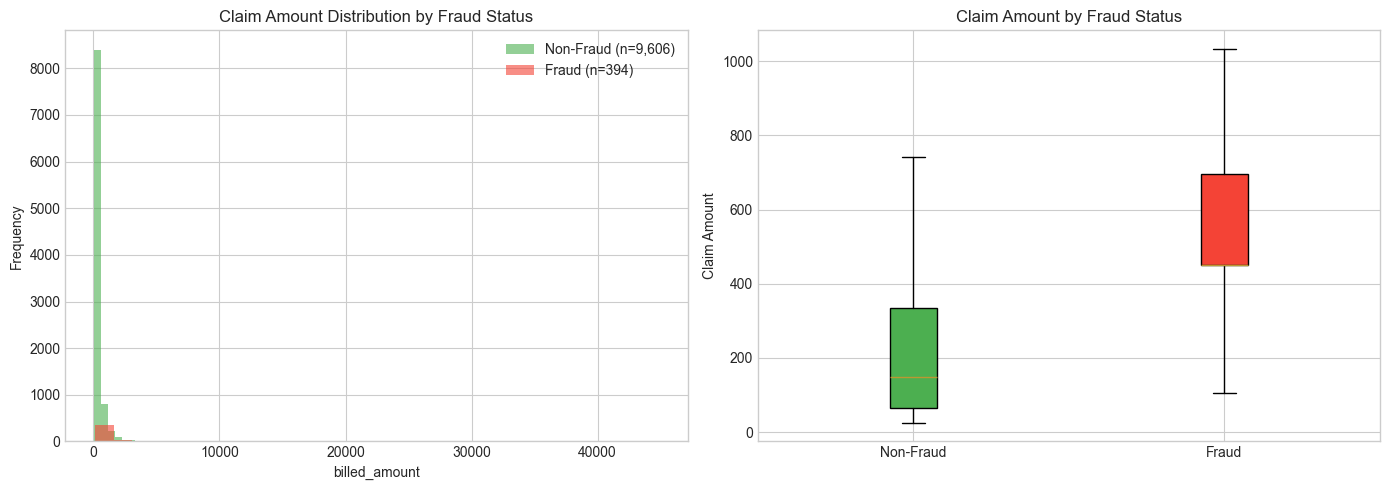


Non-Fraud:
  Mean: 302.51
  Median: 148.39
  Count: 9,606

Fraud:
  Mean: 1012.87
  Median: 450.00
  Count: 394


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram by fraud status
for status, color in zip([0, 1], ['#4CAF50', '#F44336']):
    subset = df[df['is_anomaly'] == status]['billed_amount']
    axes[0].hist(subset, bins=30, alpha=0.6, label=f"{'Non-Fraud' if status == 0 else 'Fraud'} (n={len(subset):,})", color=color)
axes[0].set_xlabel('billed_amount')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Claim Amount Distribution by Fraud Status')
axes[0].legend()

# Box plot by fraud status
data_to_plot = [df[df['is_anomaly'] == 0]['billed_amount'], df[df['is_anomaly'] == 1]['billed_amount']]
bp = axes[1].boxplot(data_to_plot, labels=['Non-Fraud', 'Fraud'], patch_artist=True, showfliers=False)
bp['boxes'][0].set_facecolor('#4CAF50')
bp['boxes'][1].set_facecolor('#F44336')
axes[1].set_ylabel('Claim Amount')
axes[1].set_title('Claim Amount by Fraud Status')

plt.tight_layout()
plt.show()

# Statistics by fraud status
for status, label in [(0, 'Non-Fraud'), (1, 'Fraud')]:
    subset = df[df['is_anomaly'] == status]['billed_amount']
    print(f"\n{label}:")
    print(f"  Mean: {subset.mean():.2f}")
    print(f"  Median: {subset.median():.2f}")
    print(f"  Count: {len(subset):,}")